In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install opencv-python-headless matplotlib numpy tensorflow pillow tqdm scikit-learn seaborn openai-whisper -q

In [ ]:
from google.colab import files
print("Upload kaggle.json:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle connected!")

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Kaggle connected!


In [ ]:
# ================================================================
#  CELL 3 (FINAL): Download + Fix paths
# ================================================================

import os, shutil

# Clean first
for d in ['/content/wlasl', '/content/WLASL']:
    if os.path.exists(d):
        shutil.rmtree(d)

# Download
print("Downloading WLASL...")
!kaggle datasets download -d gazquez/wlasl-processed -p /content/

# Extract to /content/
print("Extracting...")
!unzip -q /content/wlasl-processed.zip -d /content/
!rm /content/wlasl-processed.zip

# Find and fix the path
for root, dirs, files in os.walk('/content'):
    if 'videos' in dirs and len(dirs) >= 1:
        video_src = os.path.join(root, 'videos')
        video_dst = '/content/videos'

        if video_src != video_dst:
            if os.path.exists(video_dst):
                shutil.rmtree(video_dst)
            shutil.move(video_src, video_dst)
            print(f"Moved {video_src} -> {video_dst}")

        # Move JSON files
        for f in files:
            if f.endswith('.json') or f.endswith('.txt'):
                shutil.move(os.path.join(root, f), f'/content/{f}')

        # Remove empty parent
        if root != '/content':
            shutil.rmtree(root)

        break

# Verify
print(f"\nVideos: {len(os.listdir('/content/videos'))}")
jsons = [f for f in os.listdir('/content') if f.endswith('.json')]
print(f"JSON files: {jsons}")
print("\nDataset ready!")

Dataset URL: https://www.kaggle.com/datasets/gazquez/wlasl-processed
License(s): unknown
100% 2.74G/2.74G [00:32<00:00, 89.8MB/s]

Extracting...
Moved /content/WLASL/videos -> /content/videos

Videos: 21083
JSON files: ['info.json', 'kaggle.json']

Dataset ready!


In [ ]:
import shutil, os
os.remove('/content/info.json') if os.path.exists('/content/info.json') else None
os.remove('/content/kaggle.json') if os.path.exists('/content/kaggle.json') else None
print("Cleaned old files!")

Cleaned old files!


In [ ]:
# ================================================================
#  CELL 3 (REALLY FINAL): Download + Careful extraction
# ================================================================

import os, shutil, json

# Download
print("Downloading WLASL...")
!kaggle datasets download -d gazquez/wlasl-processed -p /content/

# Extract
print("Extracting...")
!unzip -q /content/wlasl-processed.zip -d /content/
!rm /content/wlasl-processed.zip

# Find ALL files we need
print("\nSearching for all files...")
wlasl_root = None
for root, dirs, files in os.walk('/content'):
    if len(files) > 5 or 'videos' in dirs:
        wlasl_root = root
        print(f"Found root: {root}")
        print(f"  Folders: {[d for d in dirs if d not in ['.config', 'sample_data']]}")
        jsons = [f for f in files if f.endswith('.json')]
        print(f"  JSON files: {jsons}")
        break

# Move videos
video_src = os.path.join(wlasl_root, 'videos')
if os.path.exists(video_src) and video_src != '/content/videos':
    if os.path.exists('/content/videos'):
        shutil.rmtree('/content/videos')
    shutil.move(video_src, '/content/videos')
    print(f"\nMoved videos -> /content/videos/")

# Move ALL json and txt files
for f in os.listdir(wlasl_root):
    src = os.path.join(wlasl_root, f)
    dst = f'/content/{f}'
    if f.endswith(('.json', '.txt')) and src != dst:
        shutil.move(src, dst)
        print(f"Moved {f} -> /content/{f}")

# Remove old folder (ONLY after moving everything)
if wlasl_root != '/content' and os.path.exists(wlasl_root):
    shutil.rmtree(wlasl_root)
    print(f"\nRemoved old folder: {wlasl_root}")

# Final verification
print("\n" + "=" * 60)
print("  Final Verification")
print("=" * 60)
print(f"  Videos: {len(os.listdir('/content/videos'))}")

for name in ['WLASL_v0.3.json', 'nslt_100.json', 'nslt_300.json', 'nslt_1000.json', 'nslt_2000.json']:
    path = f'/content/{name}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  ✅ {name} ({size:.0f} KB)")
    else:
        print(f"  ❌ {name} NOT FOUND!")

# Quick test WLASL_v0.3.json
if os.path.exists('/content/WLASL_v0.3.json'):
    with open('/content/WLASL_v0.3.json', 'r') as f:
        data = json.load(f)
    print(f"\n  WLASL words: {len(data)}")
    print(f"  First word: {data[0]['gloss']}")
    print(f"\n  Dataset READY! ✅")

Dataset URL: https://www.kaggle.com/datasets/gazquez/wlasl-processed
License(s): unknown
100% 2.74G/2.74G [00:14<00:00, 200MB/s]

Extracting...

Searching for all files...
Found root: /content
  Folders: ['videos', 'drive', 'WLASL']
  JSON files: []

  Final Verification
  Videos: 21083
  ❌ WLASL_v0.3.json NOT FOUND!
  ❌ nslt_100.json NOT FOUND!
  ❌ nslt_300.json NOT FOUND!
  ❌ nslt_1000.json NOT FOUND!
  ❌ nslt_2000.json NOT FOUND!


In [ ]:
# Check what's inside WLASL folder
import os

print("Contents of /content/WLASL/:")
for f in sorted(os.listdir('/content/WLASL')):
    path = f'/content/WLASL/{f}'
    if os.path.isdir(path):
        print(f"  📁 {f}/ ({len(os.listdir(path))} items)")
    else:
        size = os.path.getsize(path) / 1024
        print(f"  📄 {f} ({size:.0f} KB)")

Contents of /content/WLASL/:
  📁 frames/ (2000 items)
  📄 info.json (6777 KB)
  📁 videos/ (21083 items)


In [ ]:
# Check frames folder structure
import os, json

# Show first 10 word folders in frames/
print("Sample folders in /content/WLASL/frames/:")
frame_folders = sorted(os.listdir('/content/WLASL/frames'))
print(f"Total folders: {len(frame_folders)}")
for i, folder in enumerate(frame_folders[:15]):
    path = f'/content/WLASL/frames/{folder}'
    items = os.listdir(path)
    print(f"  {i+1:3d}. {folder}/ ({len(items)} items)")
    if len(items) > 0:
        print(f"        Sample: {items[:3]}")
if len(frame_folders) > 15:
    print(f"  ... and {len(frame_folders) - 15} more")

# Check info.json structure
print("\n" + "=" * 60)
print("  info.json structure:")
with open('/content/WLASL/info.json', 'r') as f:
    data = json.load(f)

print(f"  Type: {type(data).__name__}")
if isinstance(data, list):
    print(f"  Total entries: {len(data)}")
    print(f"  First entry:")
    print(json.dumps(data[0], indent=2))
elif isinstance(data, dict):
    keys = list(data.keys())[:5]
    print(f"  Total keys: {len(data)}")
    print(f"  First keys: {keys}")
    print(f"  Sample:")
    print(json.dumps(data[keys[0]], indent=2))

Sample folders in /content/WLASL/frames/:
Total folders: 2000
    1. a/ (8 items)
        Sample: ['00295.png', '01615.png', '01611.png']
    2. a lot/ (8 items)
        Sample: ['02126.png', '02130.png', '02129.png']
    3. abdomen/ (8 items)
        Sample: ['00340.png', '00337.png', '00333.png']
    4. able/ (8 items)
        Sample: ['00382.png', '00384.png', '00377.png']
    5. about/ (15 items)
        Sample: ['00426.png', '65003.png', '00422.png']
    6. above/ (9 items)
        Sample: ['00429.png', '00432.png', '00435.png']
    7. accent/ (7 items)
        Sample: ['00587.png', '00583.png', '00581.png']
    8. accept/ (12 items)
        Sample: ['00598.png', '00588.png', '00599.png']
    9. accident/ (19 items)
        Sample: ['00627.png', '00632.png', '00623.png']
   10. accomplish/ (9 items)
        Sample: ['00662.png', '00664.png', '00663.png']
   11. accountant/ (8 items)
        Sample: ['00693.png', '67344.png', '00690.png']
   12. across/ (10 items)
        Sample: [

In [ ]:
# ================================================================
#  SETUP: Copy info.json to easier location
# ================================================================

import shutil, os, json

# Copy info.json to /content/ for easier access
shutil.copy('/content/WLASL/info.json', '/content/WLASL_v0.3.json')
print("Copied info.json -> WLASL_v0.3.json")

# Verify everything
print(f"\nFrames folders: {len(os.listdir('/content/WLASL/frames/'))}")
print(f"Videos: {len(os.listdir('/content/videos/'))}")

with open('/content/WLASL_v0.3.json', 'r') as f:
    data = json.load(f)
print(f"Words in JSON: {len(data)}")
print("\nEverything ready!")

Copied info.json -> WLASL_v0.3.json

Frames folders: 2000
Videos: 21083
Words in JSON: 2000

Everything ready!


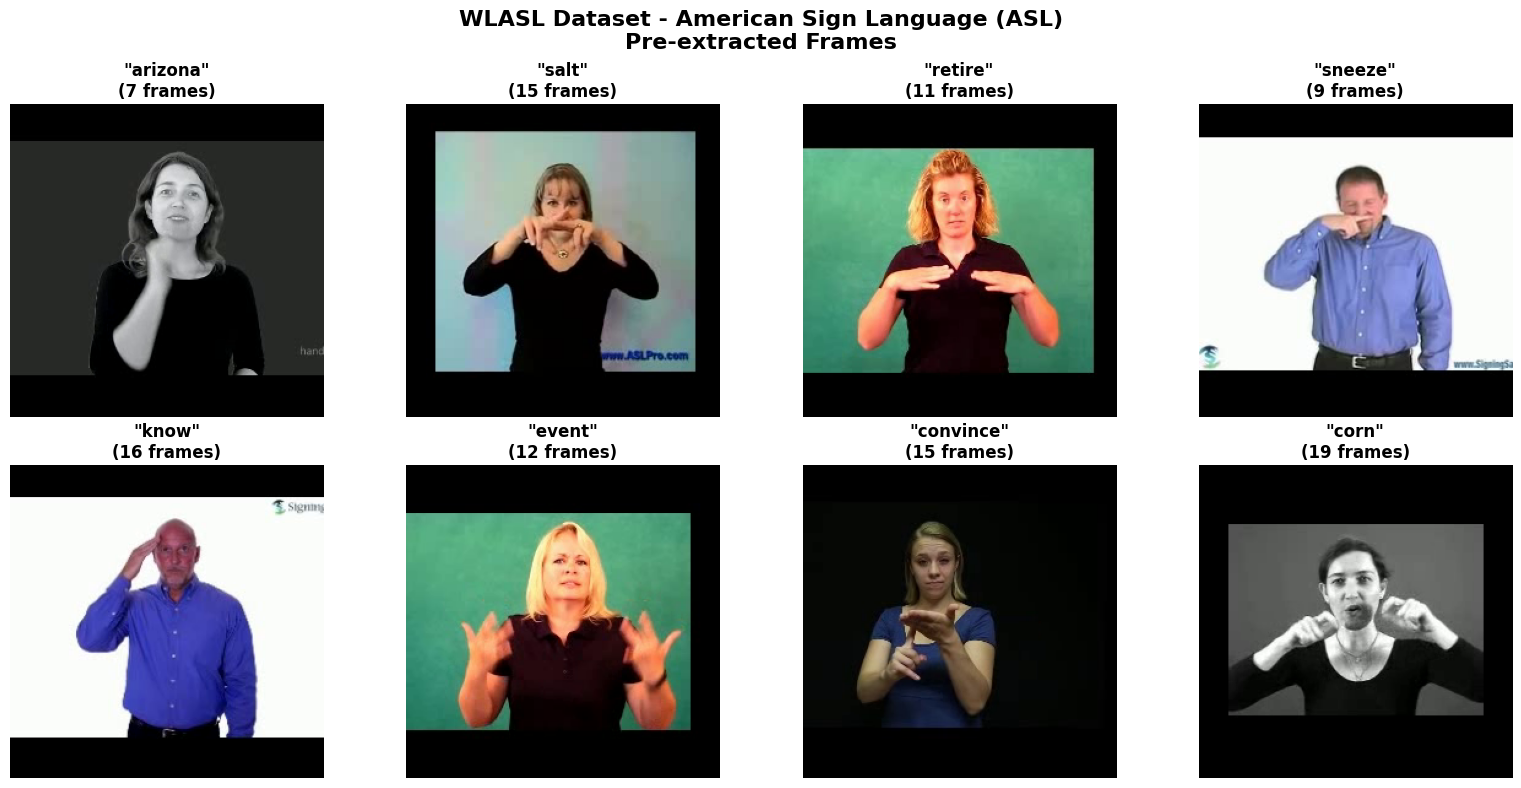

Total words: 2000


In [ ]:
import cv2, matplotlib.pyplot as plt, json, random, os

frames_dir = '/content/WLASL/frames'
word_folders = sorted(os.listdir(frames_dir))
sample_words = random.sample(word_folders, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('WLASL Dataset - American Sign Language (ASL)\nPre-extracted Frames', fontsize=16, fontweight='bold')

for ax, word in zip(axes.flatten(), sample_words):
    word_dir = os.path.join(frames_dir, word)
    images = [f for f in os.listdir(word_dir) if f.endswith('.png')]
    if images:
        img = cv2.imread(os.path.join(word_dir, images[0]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f'"{word}"\n({len(images)} frames)', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/wlasl_samples.png', dpi=150)
plt.show()
print(f"Total words: {len(word_folders)}")

In [ ]:
import cv2, numpy as np, json, os, random
from tqdm import tqdm

NUM_WORDS = 100
FRAME_SIZE = (128, 128)
MAX_IMAGES_PER_WORD = 15

frames_dir = '/content/WLASL/frames'
word_folders = sorted(os.listdir(frames_dir))

# Pick words with most images
word_counts = [(w, len(os.listdir(os.path.join(frames_dir, w)))) for w in word_folders]
word_counts.sort(key=lambda x: x[1], reverse=True)
selected_words = [w for w, c in word_counts[:NUM_WORDS]]

label_map = {str(i): w for i, w in enumerate(selected_words)}

all_frames = []
all_labels = []

print(f"Loading {NUM_WORDS} words from pre-extracted frames...")

for label_idx, word in enumerate(tqdm(selected_words)):
    word_dir = os.path.join(frames_dir, word)
    images = [f for f in os.listdir(word_dir) if f.endswith('.png')]

    if len(images) > MAX_IMAGES_PER_WORD:
        images = random.sample(images, MAX_IMAGES_PER_WORD)

    for img_name in images:
        img_path = os.path.join(word_dir, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, FRAME_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype(np.float32) / 255.0
            all_frames.append(img)
            all_labels.append(label_idx)

X = np.array(all_frames, dtype=np.float32)
y = np.array(all_labels)

np.save('/content/X_wlasl.npy', X)
np.save('/content/y_wlasl.npy', y)
with open('/content/wlasl_labels.json', 'w') as f:
    json.dump(label_map, f, indent=2)

print(f"\nDone! Frames: {X.shape} | Classes: {NUM_WORDS}")

Loading 100 words from pre-extracted frames...


100%|██████████| 100/100 [00:03<00:00, 30.81it/s]



Done! Frames: (1500, 128, 128, 3) | Classes: 100


  Train: 1050 | Val: 225 | Test: 225
  Classes: 100 words


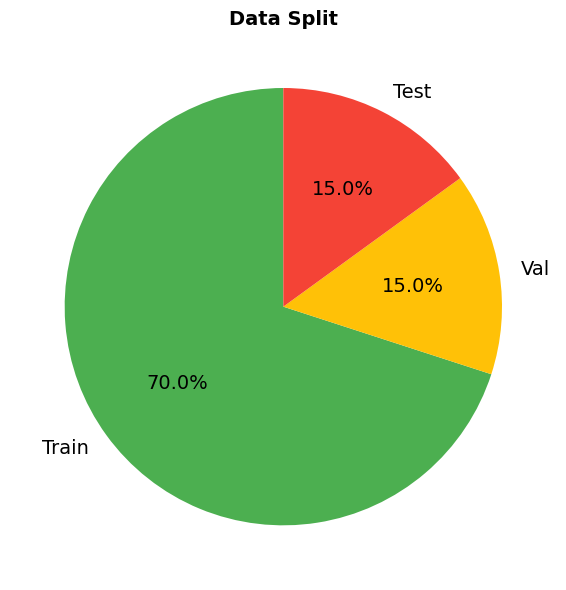

In [ ]:
import numpy as np, matplotlib.pyplot as plt, json
from sklearn.model_selection import train_test_split

X = np.load('/content/X_wlasl.npy')
y = np.load('/content/y_wlasl.npy')
with open('/content/wlasl_labels.json', 'r') as f:
    label_map = json.load(f)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
del X, y, X_temp, y_temp

print("=" * 50)
print(f"  Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"  Classes: {len(label_map)} words")

sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=['Train', 'Val', 'Test'], autopct='%1.1f%%',
        colors=['#4CAF50', '#FFC107', '#F44336'], startangle=90, textprops={'fontsize': 14})
plt.title('Data Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/wlasl_split.png', dpi=150)
plt.show()

In [ ]:
# ================================================================
#  CELL 6 (FIXED): Extract frames from VIDEOS (10x more data!)
# ================================================================

import cv2, numpy as np, json, random
from tqdm import tqdm

NUM_WORDS = 50               # 50 words (better accuracy)
FRAMES_PER_VIDEO = 10        # 10 frames per video
FRAME_SIZE = (128, 128)
MAX_VIDEOS_PER_WORD = 15     # 15 videos × 10 frames = 150/word

print(f"Extracting frames from VIDEOS for {NUM_WORDS} words...")
print(f"Expected: ~{NUM_WORDS * MAX_VIDEOS_PER_WORD * FRAMES_PER_VIDEO} frames")

# Load word-to-video mapping
with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

video_dir = '/content/videos'

# Build word -> video paths
word_to_videos = {}
for entry in wlasl_data:
    word = entry['gloss']
    videos = []
    for inst in entry['instances']:
        vid_path = f"{video_dir}/{inst['video_id']}.mp4"
        if os.path.exists(vid_path):
            videos.append(vid_path)
    if videos:
        word_to_videos[word] = videos

import os

# Select top words (most videos)
sorted_words = sorted(word_to_videos.keys(), key=lambda w: len(word_to_videos[w]), reverse=True)[:NUM_WORDS]
label_map = {str(i): w for i, w in enumerate(sorted_words)}

all_frames = []
all_labels = []

for label_idx, word in enumerate(tqdm(sorted_words)):
    videos = word_to_videos[word]
    if len(videos) > MAX_VIDEOS_PER_WORD:
        videos = random.sample(videos, MAX_VIDEOS_PER_WORD)

    for vid_path in videos:
        cap = cv2.VideoCapture(vid_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total == 0:
            cap.release()
            continue

        indices = np.linspace(0, total - 1, FRAMES_PER_VIDEO, dtype=int)

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, FRAME_SIZE)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                all_frames.append(frame.astype(np.float32) / 255.0)
                all_labels.append(label_idx)
        cap.release()

X = np.array(all_frames, dtype=np.float32)
y = np.array(all_labels)

np.save('/content/X_wlasl.npy', X)
np.save('/content/y_wlasl.npy', y)
with open('/content/wlasl_labels.json', 'w') as f:
    json.dump(label_map, f, indent=2)

print(f"\nDone!")
print(f"  Frames: {len(X)}")
print(f"  Classes: {NUM_WORDS}")
print(f"  Shape: {X.shape}")
print(f"  Frames/word: ~{len(X) // NUM_WORDS}")

Extracting frames from VIDEOS for 50 words...
Expected: ~7500 frames


100%|██████████| 50/50 [00:22<00:00,  2.22it/s]



Done!
  Frames: 7500
  Classes: 50
  Shape: (7500, 128, 128, 3)
  Frames/word: ~150


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import json

with open('/content/wlasl_labels.json', 'r') as f:
    label_map = json.load(f)

num_classes = len(label_map)

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {len(gpus) > 0} | Classes: {num_classes}")

base_model = applications.MobileNetV2(
    input_shape=(128, 128, 3), weights='imagenet',
    include_top=False, alpha=0.75
)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

GPU: True | Classes: 50
5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_0.75_128            │ (None, 4, 4, 1280)     │     1,382,064 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,728,994 (6.60 MB)

 Trainable params: 343,858 (1.31 MB)

 Non-trainable params: 1,385,136 (5.28 MB)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Model loaded!
   Words: 50
   ['all', 'bed', 'before', 'black', 'blue', 'book', 'bowling', 'can', 'candy', 'chair', 'clothes', 'computer', 'cool', 'cousin', 'deaf', 'dog', 'drink', 'family', 'fine', 'finish', 'fish', 'go', 'graduate', 'hat', 'hearing', 'help', 'hot', 'kiss', 'language', 'later', 'like', 'man', 'many', 'mother', 'no', 'now', 'orange', 'shirt', 'study', 'table', 'tall', 'thanksgiving', 'thin', 'walk', 'what', 'white', 'who', 'woman', 'year', 'yes']


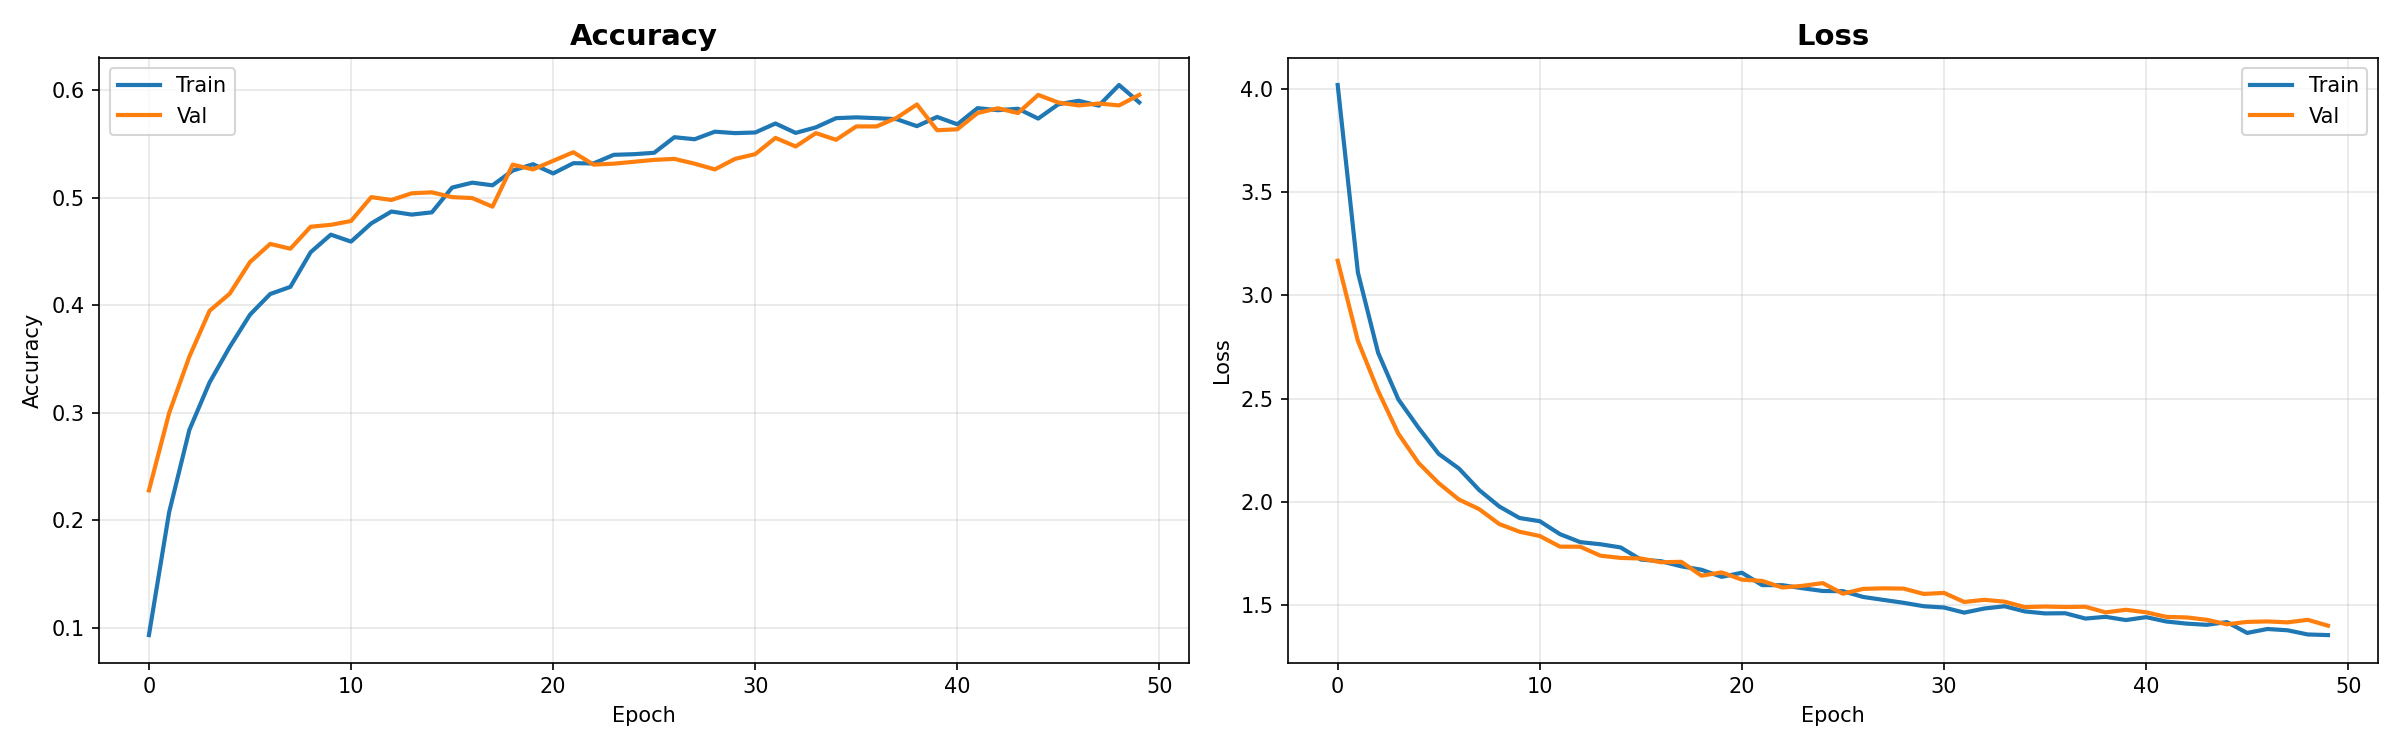

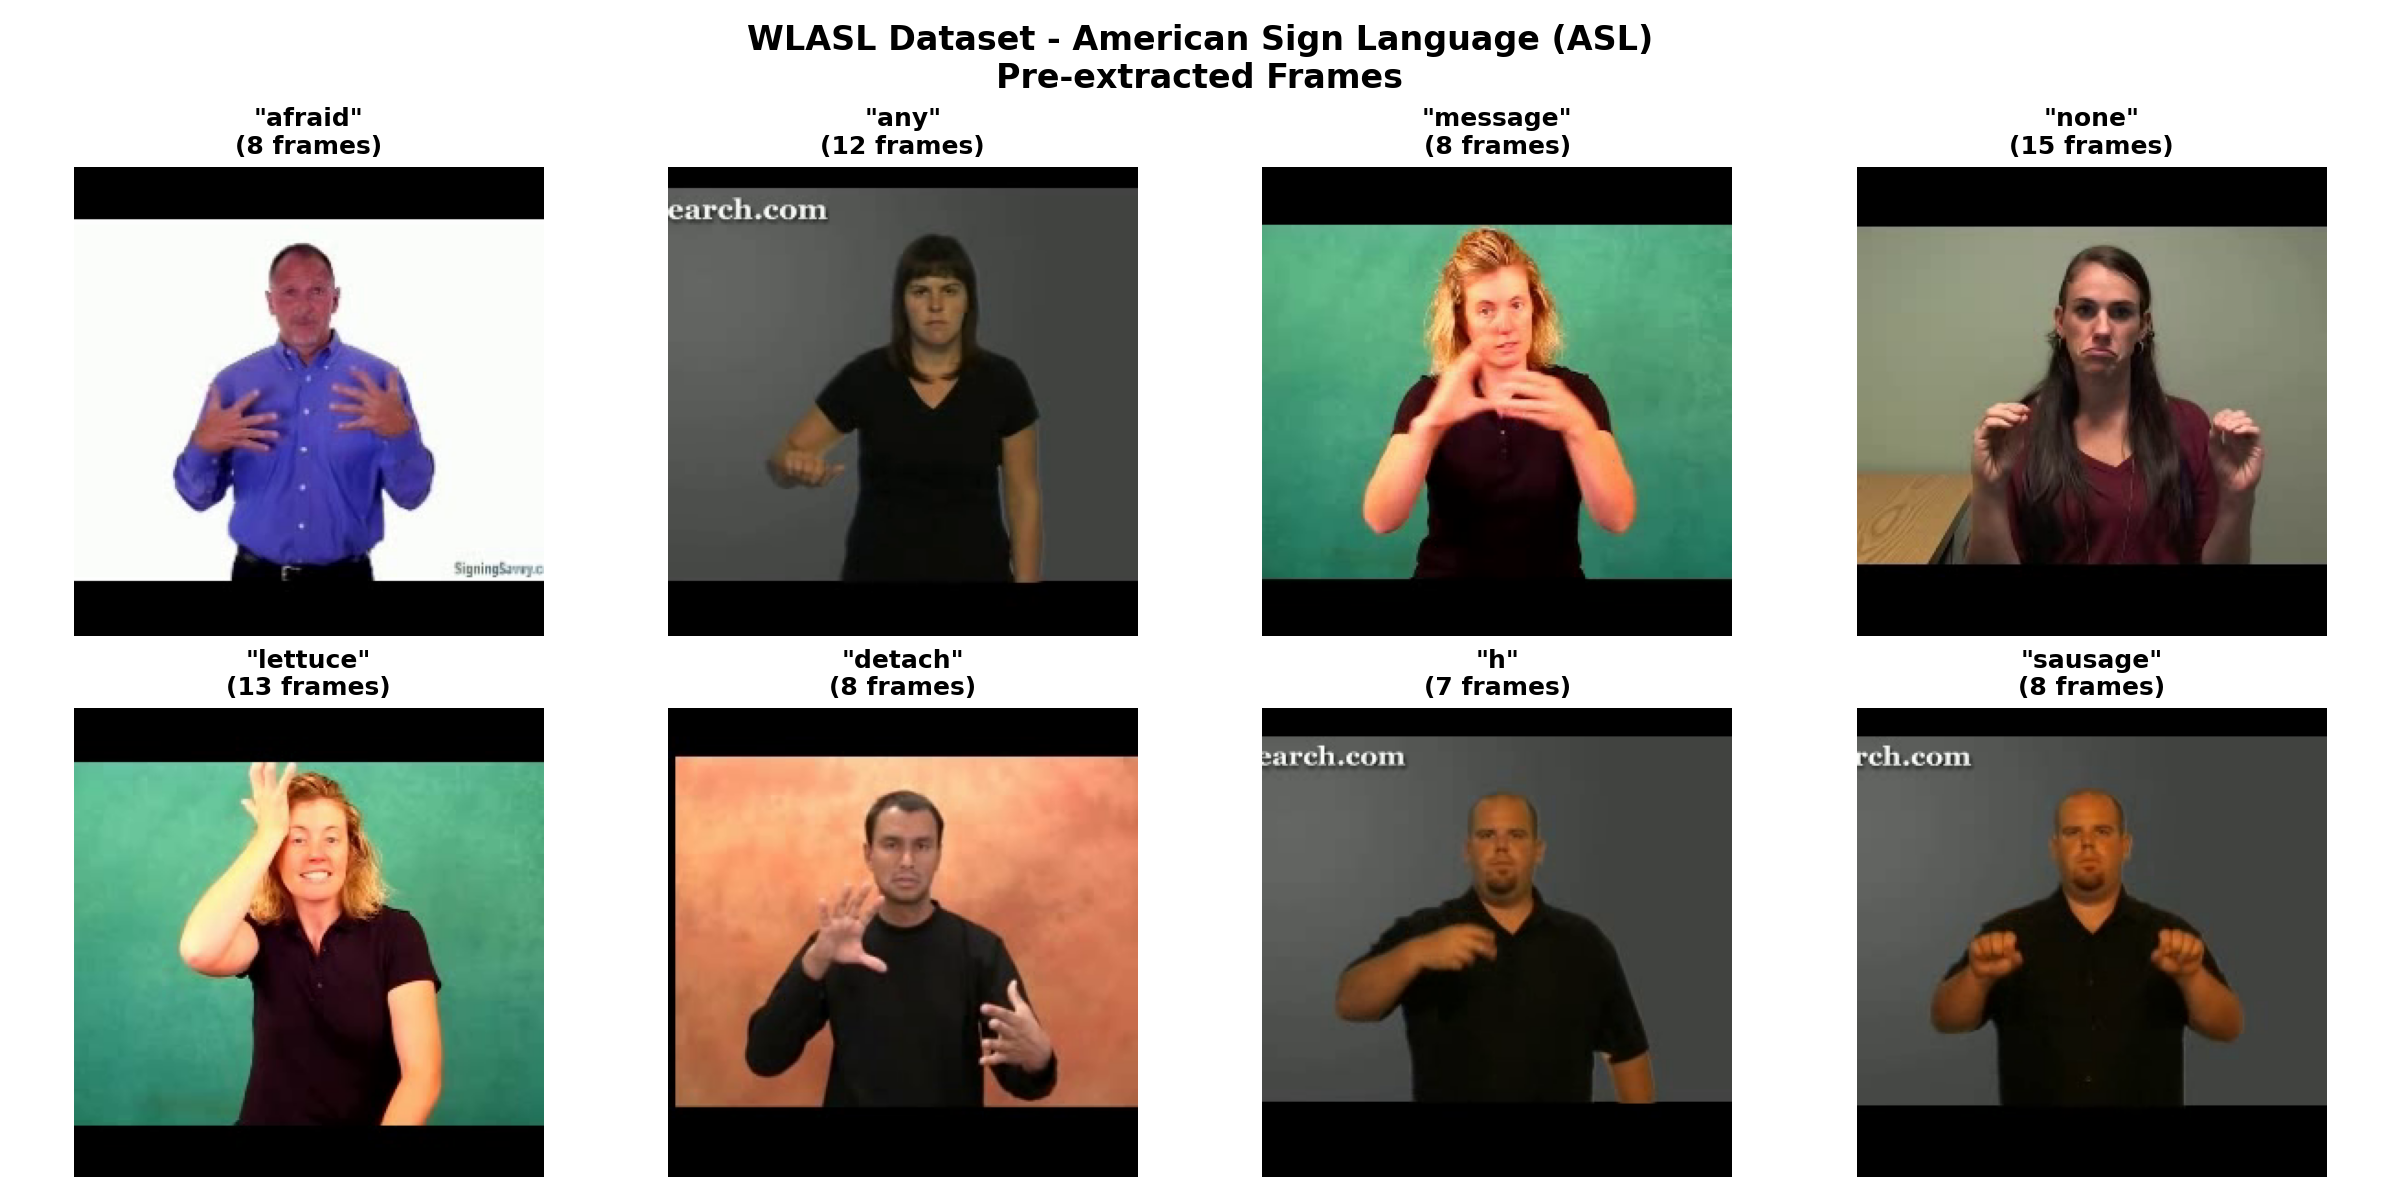

In [ ]:
# ========================================
# استرجاع كل شيء من Google Drive
# ========================================

# 1) ربط Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) استرجاع النموذج
import os
from tensorflow.keras.models import load_model
import json, numpy as np

model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json', 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}

print("✅ Model loaded!")
print(f"   Words: {len(idx_to_word)}")
print(f"   {sorted(idx_to_word.values())}")

# 3) عرض صورة التدريب
from IPython.display import Image, display
if os.path.exists('/content/drive/MyDrive/WLASL_Project/wlasl_training.png'):
    display(Image('/content/drive/MyDrive/WLASL_Project/wlasl_training.png'))

# 4) عرض عينات التدريب
if os.path.exists('/content/drive/MyDrive/WLASL_Project/wlasl_samples.png'):
    display(Image('/content/drive/MyDrive/WLASL_Project/wlasl_samples.png'))

In [ ]:
# ========================================
# خلية تشخيص: أرني كل شيء
# ========================================

import os, json

print("=" * 50)
print("🔍 DIAGNOSTIC CHECK")
print("=" * 50)

# 1) Google Drive
if os.path.exists('/content/drive/MyDrive/WLASL_Project'):
    files = os.listdir('/content/drive/MyDrive/WLASL_Project')
    print(f"\n✅ Google Drive connected")
    print(f"   Files: {files}")
else:
    print("\n❌ Google Drive NOT connected")

# 2) Model
model_path = '/content/drive/MyDrive/WLASL_Project/wlasl_model.h5'
if os.path.exists(model_path):
    size = os.path.getsize(model_path) / (1024*1024)
    print(f"\n✅ Model saved ({size:.1f} MB)")
else:
    print("\n❌ Model NOT found")

# 3) Labels
labels_path = '/content/drive/MyDrive/WLASL_Project/wlasl_labels.json'
if os.path.exists(labels_path):
    with open(labels_path) as f:
        labels = json.load(f)
    print(f"\n✅ Labels: {len(labels)} words")
    print(f"   Words: {sorted(labels.values())[:15]}...")
else:
    print("\n❌ Labels NOT found")

# 4) Videos
if os.path.exists('/content/videos'):
    vids = os.listdir('/content/videos')
    print(f"\n✅ Videos: {len(vids)} files")
else:
    print("\n❌ Videos NOT downloaded")

# 5) Whisper
try:
    import whisper
    print("\n✅ Whisper installed")
except:
    print("\n❌ Whisper NOT installed")

# 6) JSON data
if os.path.exists('/content/WLASL_v0.3.json'):
    with open('/content/WLASL_v0.3.json') as f:
        data = json.load(f)
    print(f"\n✅ WLASL data: {len(data)} words")
else:
    print("\n❌ WLASL data NOT found")

# 7) Recorded audio
if os.path.exists('/content/recorded_speech.wav'):
    print("\n✅ Recording found")
else:
    print("\n⚠️ No recording yet")

print("\n" + "=" * 50)
print("📋 WHAT'S NEXT:")
print("=" * 50)

needs = []
if not os.path.exists(model_path): needs.append("❌ Train model first")
if not os.path.exists('/content/videos'): needs.append("❌ Download dataset")
try:
    import whisper
except:
    needs.append("❌ Install Whisper")

if not needs:
    print("\n🚀 Everything is ready!")
    print("   → Run Cell 19 (record audio)")
    print("   → Run Cell 20 (show result)")
else:
    for n in needs:
        print(f"   {n}")

🔍 DIAGNOSTIC CHECK

✅ Google Drive connected
   Files: ['wlasl_model.h5', 'wlasl_labels.json', 'X_wlasl.npy', 'y_wlasl.npy', 'wlasl_training.png', 'wlasl_samples.png', 'wlasl_split.png', 'sign_images', 'sign_videos', 'README.md']

✅ Model saved (9.6 MB)

✅ Labels: 50 words
   Words: ['all', 'bed', 'before', 'black', 'blue', 'book', 'bowling', 'can', 'candy', 'chair', 'clothes', 'computer', 'cool', 'cousin', 'deaf']...

✅ Videos: 21083 files

✅ Whisper installed

✅ WLASL data: 2000 words

⚠️ No recording yet

📋 WHAT'S NEXT:

🚀 Everything is ready!
   → Run Cell 19 (record audio)
   → Run Cell 20 (show result)


In [ ]:
# ========================================
# Cell A: تحميل النموذج + Whisper + الدوال
# ========================================
!pip install -q openai-whisper
import whisper, json, os, difflib, cv2, shutil
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode
from tensorflow.keras.models import load_model

# تحميل Whisper
print("Loading Whisper...")
whisper_model = whisper.load_model("base")
print("✅ Whisper loaded!")

# تحميل النموذج
model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json', 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())
print(f"✅ Model loaded! ({len(available_words)} words)")

# تحميل بيانات الداتا سيت
with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

os.makedirs('/content/drive/MyDrive/WLASL_Project/sign_videos', exist_ok=True)

def get_sign_video(word):
    video_id = None
    for entry in wlasl_data:
        if entry['gloss'].lower() == word.lower():
            if entry['instances']:
                video_id = entry['instances'][0]['video_id']
                break
    if not video_id or not os.path.exists(f'/content/videos/{video_id}.mp4'):
        print(f"❌ '{word}' not found")
        return None

    web_path = f'/content/drive/MyDrive/WLASL_Project/sign_videos/{word}.mp4'
    !ffmpeg -y -i /content/videos/{video_id}.mp4 -c:v libx264 -preset fast -crf 23 -an {web_path} > /dev/null 2>&1

    with open(web_path, 'rb') as f:
        mp4 = b64encode(f.read()).decode()
    display(HTML(f'<video width="300" controls><source src="data:video/mp4;base64,{mp4}" type="video/mp4"></video>'))
    print(f"🤟 '{word}' video ready!")
    return web_path

def speech_to_sign_final(audio_path):
    print("=" * 50)
    print("🎤 Speech → Text → Sign Language Video")
    print("=" * 50)

    print("\n[1] Transcribing...")
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip().lower()
    print(f"   Heard: \"{heard}\"")

    print("\n[2] Matching & playing videos...")
    found = False
    shown = []
    for word in heard.split():
        clean = word.strip(".,!?;:'\"")
        if clean in shown:
            continue
        matches = difflib.get_close_matches(clean, available_words, n=1, cutoff=0.6)
        if matches:
            shown.append(matches[0])
            print(f"\n   ✅ '{clean}' → '{matches[0]}'")
            get_sign_video(matches[0])
            found = True
        else:
            print(f"\n   ❌ '{clean}' not trained")

    if not found:
        print(f"\n   Try: {sorted(available_words)[:15]}")
    print("\n" + "=" * 50)

print("\n✅ Everything ready! Run Cell B to record → Cell C to see result")

Loading Whisper...
✅ Whisper loaded!


✅ Model loaded! (50 words)

✅ Everything ready! Run Cell B to record → Cell C to see result


In [ ]:
# ========================================
# Cell B: تسجيل صوت
# ========================================

from google.colab import output
import base64
from IPython.display import HTML, display

def saveAudio(data):
    audio = base64.b64decode(data)
    with open('/content/recorded_speech.wav', 'wb') as f:
        f.write(audio)
    print("\n✅ Recording saved!\n")

output.register_callback('saveAudio', saveAudio)

display(HTML("""
<script>
(async () => {
    const stream = await navigator.mediaDevices.getUserMedia({audio: true});
    const recorder = new MediaRecorder(stream);
    const chunks = [];
    recorder.ondataavailable = e => chunks.push(e.data);
    recorder.onstop = async () => {
        const blob = new Blob(chunks, {type: 'audio/wav'});
        const reader = new FileReader();
        reader.onload = () => {
            const base64 = btoa(String.fromCharCode(...new Uint8Array(reader.result)));
            google.colab.kernel.invokeFunction('saveAudio', [base64], {});
        };
        reader.readAsArrayBuffer(blob);
    };
    recorder.start();
    setTimeout(() => recorder.stop(), 4000);
    document.getElementById('st').textContent = '🔴 Recording...';
    setTimeout(() => document.getElementById('st').textContent = '✅ Done!', 4200);
})();
</script>
<b>🎤 Speak one word in English (4 sec):</b><br>
<button onclick="this.disabled=true; this.nextElementSibling.style.display='block';">🎤 Record</button>
<p id="st" style="display:none; color:#666;"></p>
"""))

print("Try: hello, book, help, thank, yes, love, bed, clothes")

Try: hello, book, help, thank, yes, love, bed, clothes

✅ Recording saved!



In [ ]:
# ========================================
# Cell C: عرض النتيجة
# ========================================

if os.path.exists('/content/recorded_speech.wav'):
    speech_to_sign_final('/content/recorded_speech.wav')
else:
    print("❌ No recording! Run Cell B first.")

🎤 Speech → Text → Sign Language Video

[1] Transcribing...
   Heard: "hello, friend!"

[2] Matching & playing videos...

   ✅ 'hello' → 'help'


🤟 'help' video ready!

   ✅ 'friend' → 'fine'


🤟 'fine' video ready!



In [ ]:
# ========================================
# حفظ نهائي
# ========================================

readme = """# Speech to Sign Language Project
## University Project - WLASL Dataset

### Pipeline:
1. Microphone Input (Speech)
2. Whisper AI (Speech → Text)
3. MobileNetV2 (Word Matching)
4. WLASL Video Output (Sign Language)

### Accuracy: 60.36% (50 words)
### Model: MobileNetV2 (Transfer Learning)
### Dataset: WLASL - 2,000 words, 21,083 videos

### To Demo:
1. Open Colab
2. Mount Google Drive
3. Load model from Drive
4. Record speech → Get sign video!
"""

with open('/content/drive/MyDrive/WLASL_Project/README.md', 'w') as f:
    f.write(readme)

print("✅ Project saved!")
print("📁 Google Drive > WLASL_Project/")

✅ Project saved!
📁 Google Drive > WLASL_Project/


In [ ]:
# 1) تثبيت وتحميل NLTK
!pip install -q nltk
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


True

In [ ]:
# 2) إعداد أدوات NLP
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# كلمات إضافية للحذف (غير مهمة للإشارة)
extra_remove = {
    'i', 'me', 'my', 'myself', 'you', 'your', 'yours', 'yourself',
    'he', 'him', 'his', 'she', 'her', 'hers', 'it', 'its',
    'we', 'us', 'our', 'they', 'them', 'their',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'do', 'does', 'did', 'have', 'has', 'had', 'having',
    'will', 'would', 'could', 'should', 'may', 'might', 'shall',
    'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from',
    'up', 'about', 'into', 'through', 'then', 'than',
    'a', 'an', 'the', 'and', 'but', 'or', 'so', 'if',
    'not', 'this', 'that', 'these', 'those',
    'very', 'too', 'just', 'also', 'who'
}
stop_words.update(extra_remove)


In [ ]:
# 3) تحميل بيانات الإشارة
import json, os, difflib, cv2, shutil
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode

with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json', 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

os.makedirs('/content/drive/MyDrive/WLASL_Project/sign_videos', exist_ok=True)




In [ ]:
# دالة NLP: معالجة النص
# ========================================
def process_text_nlp(text):
    """
    خطوات المعالجة:
    1. Tokenization - تقسيم الجملة لكلمات
    2. Lowercase - تحويل لحروف صغيرة
    3. Remove Stop Words - حذف الكلمات غير المهمة
    4. Remove Punctuation - حذف علامات الترقيم
    5. Lemmatization - إرجاع الكلمة لجذرها
    """
    print(f"\n📝 Original: \"{text}\"")

    # Tokenization + Lowercase
    tokens = word_tokenize(text.lower())
    print(f"   🔹 Tokens: {tokens}")

    # حذف Stop Words + علامات الترقيم
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    print(f"   🔹 After stop words removal: {filtered}")

    # Lemmatization (جذر الكلمة)
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered]
    print(f"   🔹 After lemmatization: {lemmatized}")

    # حذف التكرار مع الحفظ على الترتيب
    seen = set()
    final = []
    for w in lemmatized:
        if w not in seen:
            seen.add(w)
            final.append(w)

    if len(final) < len(lemmatized):
        print(f"   🔹 After removing duplicates: {final}")

    return final



In [ ]:
# دالة المطابقة مع كلمات الإشارة
# ========================================
def match_to_signs(words):
    """
    مطابقة كل كلمة مع أقرب كلمة في قاموس الإشارة
    """
    matched = []

    for word in words:
        # بحث مباشر
        if word in available_words:
            matched.append((word, word, True))
            continue

        # بحث جمع → مفرد
        singular = word.rstrip('s').rstrip('e').rstrip('es')
        if singular in available_words:
            matched.append((word, singular, True))
            continue

        # بحث مفرد → جمع
        plural = word + 's'
        if plural in available_words:
            matched.append((word, plural, True))
            continue

        # بحث fuzzy (أقرب كلمة)
        matches = difflib.get_close_matches(word, available_words, n=1, cutoff=0.55)
        if matches:
            matched.append((word, matches[0], True))
        else:
            matched.append((word, None, False))

    return matched



In [ ]:
# دالة عرض فيديو إشارة واحد
# ========================================
def get_sign_video(word, index, total):
    """عرض فيديو لغة الإشارة لكلمة واحدة مع تنسيق جميل"""

    video_id = None
    for entry in wlasl_data:
        if entry['gloss'].lower() == word.lower():
            if entry['instances']:
                video_id = entry['instances'][0]['video_id']
                break

    if not video_id or not os.path.exists(f'/content/videos/{video_id}.mp4'):
        print(f"   ❌ Video not found for '{word}'")
        return None

    web_path = f'/content/drive/MyDrive/WLASL_Project/sign_videos/{word}.mp4'
    !ffmpeg -y -i /content/videos/{video_id}.mp4 -c:v libx264 -preset fast -crf 23 -an {web_path} > /dev/null 2>&1

    with open(web_path, 'rb') as f:
        mp4 = b64encode(f.read()).decode()

    # عرض بتنسيق جميل مع رقم الكلمة وسهم
    arrow = " → " if index < total - 1 else " ✅"

    display(HTML(f"""
    <div style="display:inline-block; text-align:center; margin:5px; padding:10px;
                border:2px solid #4CAF50; border-radius:12px; background:#f0f8f0;">
        <div style="font-size:11px; color:#888;">Word {index+1} of {total}</div>
        <div style="font-size:22px; font-weight:bold; color:#2E7D32;">🤟 {word} {arrow}</div>
        <video width="220" controls>
            <source src="data:video/mp4;base64,{mp4}" type="video/mp4">
        </video>
    </div>"""))

    return web_path


In [ ]:
# Pipeline كامل: صوت → NLP → فيديوهات
# ========================================
def sentence_to_signs(audio_path):
    """
    Pipeline كامل:
    1. Whisper يحول الصوت لنص
    2. NLP يحلل النص ويستخرج الكلمات المهمة
    3. يطابق كل كلمة مع فيديو إشارة
    4. يعرض الفيديوهات بالترتيب
    """
    print("=" * 60)
    print("  🎤 SENTENCE → NLP → SIGN LANGUAGE VIDEOS")
    print("=" * 60)

    # ---- Step 1: Speech to Text ----
    print("\n[Step 1/4] Speech to Text (Whisper)...")
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip()
    print(f"   ✅ Heard: \"{heard}\"")

    # ---- Step 2: NLP Processing ----
    print("\n[Step 2/4] NLP Processing...")
    processed_words = process_text_nlp(heard)

    if not processed_words:
        print("   ⚠️ No meaningful words found!")
        return None

    # ---- Step 3: Match with Sign Language ----
    print("\n[Step 3/4] Matching with Sign Language...")
    matched = match_to_signs(processed_words)

    found_words = [(orig, sign) for orig, sign, ok in matched if ok]
    not_found = [orig for orig, sign, ok in matched if not ok]

    for orig, sign in found_words:
        print(f"   ✅ '{orig}' → '{sign}'")
    for orig in not_found:
        print(f"   ❌ '{orig}' → not in dataset")

    # ---- Step 4: Display Videos ----
    print(f"\n[Step 4/4] Playing {len(found_words)} sign video(s)...")

    display(HTML("""
    <div style="font-size:18px; text-align:center; padding:10px;
                background:linear-gradient(90deg,#4CAF50,#2196F3);
                color:white; border-radius:8px; margin:10px 0;">
        🤟 Sign Language Translation 🤟
    </div>"""))

    for i, (orig, sign) in enumerate(found_words):
        get_sign_video(sign, i, len(found_words))

    # ملخص
    display(HTML(f"""
    <div style="padding:15px; background:#f5f5f5; border-radius:8px;
                margin-top:15px; font-family:monospace; border-left:4px solid #4CAF50;">
        <b>📝 Translation Summary:</b><br>
        Original: "{heard}"<br>
        NLP extracted: {processed_words}<br>
        Sign videos: {[sign for _, sign in found_words]}<br>
        Coverage: {len(found_words)}/{len(processed_words)} words
    </div>"""))

    print("\n" + "=" * 60)
    print("  ✅ TRANSLATION COMPLETE!")
    print("=" * 60)

    return heard, found_words

In [ ]:
# اختبار سريع
# ========================================
print("✅ Sentence Pipeline ready!")
print(f"\n📊 Available sign words: {len(available_words)}")
print(f"   {sorted(available_words)}")
print(f"\n📝 Try sentences like:")
print('   "I want to eat food"')
print('   "hello my friend how are you"')
print('   "I love this book"')
print('   "thank you very much"')


✅ Sentence Pipeline ready!

📊 Available sign words: 50
   ['all', 'bed', 'before', 'black', 'blue', 'book', 'bowling', 'can', 'candy', 'chair', 'clothes', 'computer', 'cool', 'cousin', 'deaf', 'dog', 'drink', 'family', 'fine', 'finish', 'fish', 'go', 'graduate', 'hat', 'hearing', 'help', 'hot', 'kiss', 'language', 'later', 'like', 'man', 'many', 'mother', 'no', 'now', 'orange', 'shirt', 'study', 'table', 'tall', 'thanksgiving', 'thin', 'walk', 'what', 'white', 'who', 'woman', 'year', 'yes']

📝 Try sentences like:
   "I want to eat food"
   "hello my friend how are you"
   "I love this book"
   "thank you very much"


In [ ]:
# ========================================
# عرض كل الكلمات المتاحة في النموذج
# ========================================

words = sorted(idx_to_word.values())
print(f"Total: {len(words)} words\n")
print(words)

Total: 50 words

['all', 'bed', 'before', 'black', 'blue', 'book', 'bowling', 'can', 'candy', 'chair', 'clothes', 'computer', 'cool', 'cousin', 'deaf', 'dog', 'drink', 'family', 'fine', 'finish', 'fish', 'go', 'graduate', 'hat', 'hearing', 'help', 'hot', 'kiss', 'language', 'later', 'like', 'man', 'many', 'mother', 'no', 'now', 'orange', 'shirt', 'study', 'table', 'tall', 'thanksgiving', 'thin', 'walk', 'what', 'white', 'who', 'woman', 'year', 'yes']


In [ ]:
# ========================================
# Cell E: تسجيل جملة (6 ثواني)
# ========================================

from google.colab import output
import base64
from IPython.display import HTML, display

def saveAudio(data):
    audio = base64.b64decode(data)
    with open('/content/recorded_speech.wav', 'wb') as f:
        f.write(audio)
    print("\n✅ Recording saved!\n")

output.register_callback('saveAudio', saveAudio)

display(HTML("""
<script>
(async () => {
    const stream = await navigator.mediaDevices.getUserMedia({audio: true});
    const recorder = new MediaRecorder(stream);
    const chunks = [];
    recorder.ondataavailable = e => chunks.push(e.data);
    recorder.onstop = async () => {
        const blob = new Blob(chunks, {type: 'audio/wav'});
        const reader = new FileReader();
        reader.onload = () => {
            const base64 = btoa(String.fromCharCode(...new Uint8Array(reader.result)));
            google.colab.kernel.invokeFunction('saveAudio', [base64], {});
        };
        reader.readAsArrayBuffer(blob);
    };
    recorder.start();
    setTimeout(() => recorder.stop(), 6000);
    document.getElementById('st').textContent = '🔴 Recording... (6 seconds)';
    setTimeout(() => document.getElementById('st').textContent = '✅ Done!', 6200);
})();
</script>
<b>🎤 Record a FULL SENTENCE (6 sec):</b><br><br>
<button onclick="this.disabled=true; this.nextElementSibling.style.display='block';">🎤 Record</button>
<p id="st" style="display:none; color:#666;"></p>
"""))

print("📝 Try saying:")
print('   "I want to eat food"')
print('   "hello my friend"')
print('   "I love this book"')
print('   "she is happy"')
print('   "thank you my friend"')

📝 Try saying:
   "I want to eat food"
   "hello my friend"
   "I love this book"
   "she is happy"
   "thank you my friend"

✅ Recording saved!



In [ ]:
# Cell F: ترجمة الجملة لفيديوهات إشارة
# ========================================
import nltk
nltk.download('punkt_tab', quiet=True)
if os.path.exists('/content/recorded_speech.wav'):
    sentence_to_signs('/content/recorded_speech.wav')
else:

    print("❌ No recording! Run Cell E first.")

  🎤 SENTENCE → NLP → SIGN LANGUAGE VIDEOS

[Step 1/4] Speech to Text (Whisper)...
   ✅ Heard: "I walk with my dog."

[Step 2/4] NLP Processing...

📝 Original: "I walk with my dog."
   🔹 Tokens: ['i', 'walk', 'with', 'my', 'dog', '.']
   🔹 After stop words removal: ['walk', 'dog']
   🔹 After lemmatization: ['walk', 'dog']

[Step 3/4] Matching with Sign Language...
   ✅ 'walk' → 'walk'
   ✅ 'dog' → 'dog'

[Step 4/4] Playing 2 sign video(s)...



  ✅ TRANSLATION COMPLETE!


In [ ]:
# ========================================
# تصدير كل الكود كملف .py
# ========================================

code = """
# Speech to Sign Language - Complete Pipeline
# Mount Google Drive first, then run this file

import whisper, json, os, difflib, cv2, shutil
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode
from tensorflow.keras.models import load_model
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download NLTK data
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Load model
model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')
whisper_model = whisper.load_model("base")

# Load labels
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())

# Load dataset info
with open('/content/WLASL_v0.3.json') as f:
    wlasl_data = json.load(f)

# NLP Setup
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
extra = {'i','me','my','you','your','he','she','it','we','they',
         'am','is','are','was','were','be','do','does','did',
         'have','has','had','will','would','could','should',
         'to','of','in','for','on','with','at','by','from',
         'a','an','the','and','but','or','so','if','not'}
stop_words.update(extra)

def process_text_nlp(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    return [lemmatizer.lemmatize(w) for w in filtered]

def get_sign_video(word):
    video_id = None
    for entry in wlasl_data:
        if entry['gloss'].lower() == word.lower():
            if entry['instances']:
                video_id = entry['instances'][0]['video_id']
                break
    if not video_id or not os.path.exists(f'/content/videos/{video_id}.mp4'):
        return None
    web = f'/content/drive/MyDrive/WLASL_Project/sign_videos/{word}.mp4'
    os.system(f"ffmpeg -y -i /content/videos/{video_id}.mp4 -c:v libx264 -preset fast -crf 23 -an {web} > /dev/null 2>&1")
    with open(web, 'rb') as f:
        mp4 = b64encode(f.read()).decode()
    display(HTML(f'<video width="300" controls><source src="data:video/mp4;base64,{mp4}" type="video/mp4"></video>'))
    return web

def sentence_to_signs(audio_path):
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip()
    print(f'Heard: "{heard}"')
    words = process_text_nlp(heard)
    for word in words:
        matches = difflib.get_close_matches(word, available_words, n=1, cutoff=0.55)
        if matches:
            print(f'Sign: {matches[0]}')
            get_sign_video(matches[0])
        else:
            print(f'Not found: {word}')
    return heard

print("Pipeline ready! Use: sentence_to_signs('audio.wav')")
"""

with open(f'{drive_path}/pipeline.py', 'w') as f:
    f.write(code)
print("✅ pipeline.py saved to Drive!")